# Курсовая работа, вариант 4

**Распределение варианта:** χ-распределение (Chi distribution).

По таблице вариантов у варианта 4 указаны два параметра:

- `df` — число степеней свободы;
- `loc` — параметр смещения.

Поэтому в работе используется **сдвинутое χ-распределение**:

$$
X = loc + Y, \qquad Y \sim \chi(df).
$$

Масштабный параметр в варианте не задан, поэтому принимается фиксированным:

$$
scale = 1.
$$

## 1. Исследование распределения из варианта

В варианте 4 задано **χ-распределение** (Chi distribution) с параметрами `df` и `loc`. Стандартное χ-распределение возникает как распределение длины случайного вектора, координаты которого являются независимыми стандартными нормальными случайными величинами. Если

$$
Z_1, Z_2, \ldots, Z_{df} \sim N(0,1)
$$

и эти величины независимы, то случайная величина

$$
Y = \sqrt{Z_1^2 + Z_2^2 + \ldots + Z_{df}^2}
$$

имеет χ-распределение с `df` степенями свободы.

Исторически χ-распределение связано с задачами статистической физики и математической статистики. В физике частный случай χ-распределения при `df = 3` появляется в распределении скоростей молекул газа, рассмотренном Дж. К. Максвеллом в работах по кинетической теории газов [1]. В математической статистике близкое χ²-распределение было введено К. Пирсоном при построении критерия согласия, а затем получило развитие в работах Р. Фишера, где рассматривались свойства оценок и распределений статистик [2], [3].

Назначение χ-распределения состоит в описании модуля случайного вектора с нормально распределёнными независимыми компонентами. Поэтому оно применяется там, где исследуется не отдельная координата, а расстояние, длина, норма ошибки или величина отклонения. В научных исследованиях χ-распределение и связанные с ним распределения используются в статистическом моделировании, обработке измерений, проверке гипотез, анализе ошибок, физике газов, радиофизике, биостатистике и задачах, где возникают нормы многомерных нормальных векторов [4], [5].

В данной курсовой работе используется сдвинутая форма χ-распределения:

$$
X = loc + Y, \qquad Y \sim \chi(df).
$$

Параметр `df` отвечает за форму распределения: при увеличении `df` распределение смещается вправо и становится более симметричным. Параметр `loc` отвечает за горизонтальный сдвиг графика по оси `x`. Так как в исходной выборке встречаются отрицательные значения, наличие параметра смещения `loc` является необходимым.

## 2. Знакомство с Jupyter Notebook

В этом разделе кратко фиксируется, что Python и Jupyter используются как среда выполнения расчётов. Подробная инструкция установки в отчёте не требуется: далее важнее показать считывание данных, функции и результаты вычислений.

In [2]:
%matplotlib inline
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, special, optimize


## 2.4. Считывание выборки X из файла варианта

Считывание выполняется стандартными средствами Python: файл открывается через `open`, затем значения преобразуются в `float`.

In [3]:
X = []
print("A")
with open('Vyborka.csv', 'r') as f:
    X = list(map(float, f.readlines()))

print('Объем выборки n =', len(X))
print('Первые 10 элементов:', X[:10])
print('Минимум:', min(X))
print('Максимум:', max(X))

A
Объем выборки n = 300
Первые 10 элементов: [-6.5959, -6.603322, -6.145672, -6.999476, -6.459287, -5.859904, -5.483201, -5.723741, -4.175702, -4.340508]
Минимум: -7.468149
Максимум: -3.19778


## 2.5. Функции для вычисления статистик выборки

Ниже функции написаны вручную, без использования готовых функций для вычисления соответствующих статистик.

### 2.5.1. Сумма элементов выборки

Сумма элементов выборки вычисляется по формуле:

$$
S = \sum_{i=1}^{n} x_i.
$$

Функция `sample_sum(x)` последовательно проходит по всем элементам выборки и прибавляет их к накопленной сумме.

In [4]:
def sample_sum(x):
    s = 0.0
    for value in x:
        s += value
    return s

print('Сумма элементов выборки =', sample_sum(X))

Сумма элементов выборки = -1694.0509839999997


### 2.5.2. Выборочное среднее

Выборочное среднее показывает среднее значение элементов выборки:

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i.
$$

Функция `sample_mean(x)` использует ранее написанную функцию суммы и делит результат на объем выборки.

In [5]:
def sample_mean(x):
    return round(sample_sum(x) / len(x), 5)

print('Выборочное среднее =', sample_mean(X))

Выборочное среднее = -5.64684


### 2.5.3. Медиана

Медиана — значение, которое делит отсортированную выборку на две части. Если число элементов нечётное, берется центральный элемент. Если число элементов чётное, берется среднее двух центральных элементов.

In [6]:
def sample_median(x):
    values = sorted(x)
    n = len(values)
    mid = n // 2
    if n % 2 == 1:
        return values[mid]
    return (values[mid - 1] + values[mid]) / 2

print('Медиана =', sample_median(X))

Медиана = -5.6144345


### 2.5.4. Мода

Мода — наиболее часто встречающееся значение выборки. Для вещественных данных точные совпадения встречаются редко, поэтому значения предварительно округляются до 4 знаков после запятой. Если все значения встречаются по одному разу, мода считается отсутствующей.

In [7]:
def sample_mode(x: list, digits=4):
    rounded = [round(value, digits) for value in x]
    max_freq = max([rounded.count(i) for i in rounded])
    moda_vals = set([i for i in rounded if rounded.count(i) == max_freq])
    if max_freq == 1: return None
    else: return ", ".join(list(map(str, moda_vals)))
print(f'Мода(ы) = {sample_mode(X)}')

Мода(ы) = -5.4749, -5.106


### 2.5.5. Размах выборки

Размах показывает длину интервала, на котором находятся значения выборки:

$$
R = x_{max} - x_{min}.
$$

In [8]:
def sample_range(x):
    return max(x) - min(x)

print('Размах выборки =', sample_range(X))

Размах выборки = 4.2703690000000005


### 2.5.6. Смещенная дисперсия

Смещенная выборочная дисперсия вычисляется с делением на `n`:

$$
D = \frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2.
$$

In [9]:
def biased_variance(x):
    m = sample_mean(x)
    s = 0.0
    for value in x:
        s += (value - m) ** 2
    return round(s / len(x), 5)

print('Смещенная дисперсия =', biased_variance(X))

Смещенная дисперсия = 0.48801


### 2.5.7. Несмещенная дисперсия

Несмещенная выборочная дисперсия вычисляется с делением на `n-1`:

$$
S^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2.
$$

Такая поправка используется для устранения смещения оценки дисперсии генеральной совокупности.

In [10]:
def unbiased_variance(x):
    m = sample_mean(x)
    s = 0.0
    for value in x:
        s += (value - m) ** 2
    return s / (len(x) - 1)

print('Несмещенная дисперсия =', unbiased_variance(X))

Несмещенная дисперсия = 0.489642467461532


### 2.5.8. Выборочный начальный момент k-го порядка

Начальный момент k-го порядка вычисляется относительно нуля:

$$
\alpha_k = \frac{1}{n}\sum_{i=1}^{n}x_i^k.
$$

В работе для примера используется `k = 3`.

In [11]:
def initial_moment(x, k):
    s = 0.0
    for value in x:
        s += value ** k
    return s / len(x)

k = 3
print(f'Начальный момент {k}-го порядка =', initial_moment(X, k))

Начальный момент 3-го порядка = -188.2877638063471


### 2.5.9. Выборочный центральный момент k-го порядка

Центральный момент k-го порядка вычисляется относительно выборочного среднего:

$$
\mu_k = \frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^k.
$$

В работе для примера используется `k = 3`.

In [12]:
def central_moment(x, k):
    m = sample_mean(x)
    s = 0.0
    for value in x:
        s += (value - m) ** k
    return s / len(x)

k = 3
print(f'Центральный момент {k}-го порядка =', central_moment(X, k))

Центральный момент 3-го порядка = 0.03872983428196484


## 2.6. Результаты вычисления статистик

In [13]:
k1, k2 = 3, 3
stats_results = {
    'Кол-во элементов выборки': len(X),
    'Сумма элементов выборки': sample_sum(X),
    'Выборочное среднее': sample_mean(X),
    'Медиана выборки': sample_median(X),
    'Мода выборки': sample_mode(X),
    'Размах выборки': sample_range(X),
    'Смещенная дисперсия': biased_variance(X),
    'Несмещенная дисперсия': unbiased_variance(X),
    f'Выборочный начальный момент {k1} порядка': initial_moment(X, k1),
    f'Выборочный центральный момент {k2} порядка': central_moment(X, k2),
}

for name, value in stats_results.items():
    print(f'{name}: {value}')

Кол-во элементов выборки: 300
Сумма элементов выборки: -1694.0509839999997
Выборочное среднее: -5.64684
Медиана выборки: -5.6144345
Мода выборки: -5.4749, -5.106
Размах выборки: 4.2703690000000005
Смещенная дисперсия: 0.48801
Несмещенная дисперсия: 0.489642467461532
Выборочный начальный момент 3 порядка: -188.2877638063471
Выборочный центральный момент 3 порядка: 0.03872983428196484


## 3. Понятие эмпирической функции распределения

### 3.1. Определение и алгоритм построения

Эмпирическая функция распределения определяется формулой:

$$
F_n(x)=\frac{1}{n}\sum_{i=1}^{n}I(X_i\le x),
$$

где `I` — индикатор события. Для каждого значения `X` функция показывает долю элементов выборки, которые не превосходят `x`.

Алгоритм построения:

1. Отсортировать выборку по возрастанию.
2. Для каждого отсортированного значения `x_(i)` поставить значение функции `i/n`.
3. Построить дискретный график.

### 3.2. Функция построения эмпирической функции распределения

In [14]:
def ecdf_points(x):
    values = sorted(x)
    n = len(values)
    y = [(i + 1) / n for i in range(n)]
    return values, y


def plot_ecdf(x, title, label):
    xp, yp = ecdf_points(x)
    plt.figure(figsize=(8, 5))
    plt.step(xp, yp, where='post', label=label)
    plt.xlabel('x')
    plt.ylabel('F_n(x)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### 3.3. Формирование случайных подвыборок

Из исходной выборки `X` случайным образом выбираются подвыборки объёмом 10, 100 и 200 элементов. Эти объёмы позволяют сравнить, как меняется вид эмпирической функции распределения при увеличении числа наблюдений.


### 3.4. Построение графиков эмпирической функции распределения

Для каждой подвыборки строится ступенчатый график эмпирической функции распределения. На графиках указаны название, подписи осей и легенда.


### 3.5. Перенос построенных графиков в отчёт

Полученные ниже графики используются как иллюстрации для отчёта по пункту 3.5.


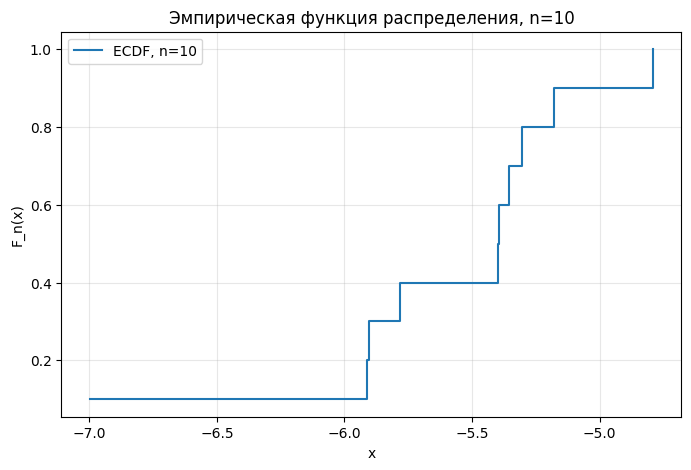

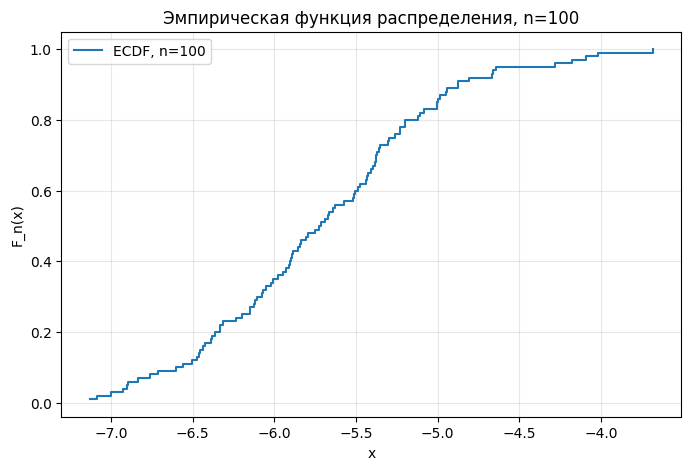

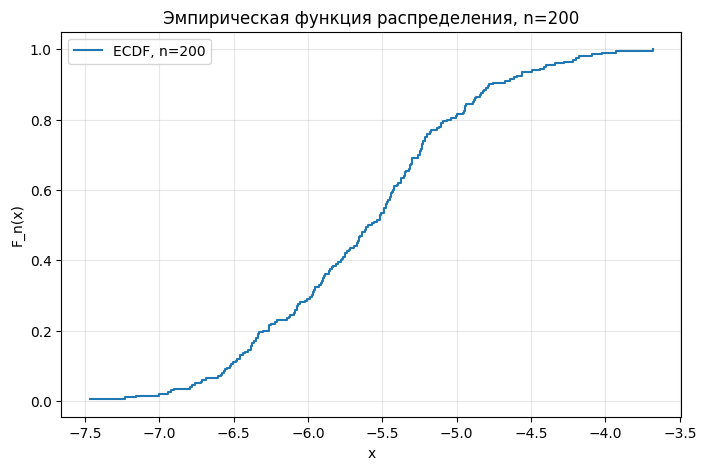

In [15]:
subsamples = {
    10: random.sample(X, 10),
    100: random.sample(X, 100),
    200: random.sample(X, 200),
}

for n_sub, sample in subsamples.items():
    plot_ecdf(sample, f'Эмпирическая функция распределения, n={n_sub}', f'ECDF, n={n_sub}')

### 3.6. Вывод о виде эмпирической функции распределения

Для малой подвыборки `n = 10` эмпирическая функция имеет грубый ступенчатый вид: скачки крупные, поэтому по ней сложно надежно судить о форме распределения. Для подвыборок `n = 100` и `n = 200` ступени становятся меньше, а график становится более гладким. Это соответствует свойству эмпирической функции распределения: при увеличении объема выборки она приближается к теоретической функции распределения.

Так как значения выборки отрицательные, а стандартная χ-случайная величина неотрицательна, можно сделать вывод о наличии отрицательного параметра смещения `loc`. Форма графика также указывает, что число степеней свободы `df` не слишком мало: распределение не имеет резкого пика около левой границы, а основная масса наблюдений расположена сравнительно компактно.

## 4. Понятие гистограммы

### 4.1. Определение и алгоритм построения

Гистограмма — графическое представление распределения выборки, при котором диапазон значений разбивается на интервалы, а высота столбца показывает частоту или плотность попадания наблюдений в соответствующий интервал.

Алгоритм построения:

1. Найти минимум и максимум выборки.
2. Разбить диапазон на несколько интервалов.
3. Посчитать количество элементов в каждом интервале.
4. При необходимости нормировать высоты столбцов так, чтобы площадь гистограммы была равна 1.

### 4.2. Функция построения гистограммы без готовой реализации

Количество столбцов определяется по формуле:

$$b = 1 + log_{2} n $$

Также устанавливаются правила:
 - Минимальное количество столбцов = 3
 - Значение формулы всегда округляется в большую сторону

In [16]:
def histogram_manual(x, bins=None):
    n = len(x)
    if bins is None:
        bins = max(3, math.ceil(1 + math.log2(n)))

    x_min, x_max = min(x), max(x)
    width = (x_max - x_min) / bins
    edges = [x_min + i * width for i in range(bins + 1)]
    counts = [0] * bins

    for value in x:
        j = bins - 1 if value == x_max else int((value - x_min) / width)
        counts[j] += 1

    density = [count / (n * width) for count in counts]
    return edges, counts, density


def plot_histogram_manual(x, title, label):
    edges, counts, density = histogram_manual(x)
    widths = [edges[i+1] - edges[i] for i in range(len(edges)-1)]
    centers = [(edges[i+1] + edges[i]) / 2 for i in range(len(edges)-1)]

    plt.figure(figsize=(8, 5))
    plt.bar(centers, density, width=widths, alpha=0.7, edgecolor='black', label=label)
    plt.xlabel('x')
    plt.ylabel('Плотность')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### 4.3. Формирование случайных подвыборок для гистограмм

Используются те же размеры подвыборок: 10, 100 и 200 элементов. Это позволяет увидеть, как объём выборки влияет на устойчивость формы гистограммы.


### 4.4. Построение гистограмм

Для каждой подвыборки строится гистограмма, причём интервалы и частоты рассчитываются вручную, без готовой функции `plt.hist`. Для отображения используется только `plt.bar`.


### 4.5. Перенос построенных гистограмм в отчёт

Построенные ниже графики используются в отчёте для визуального сравнения формы распределения.


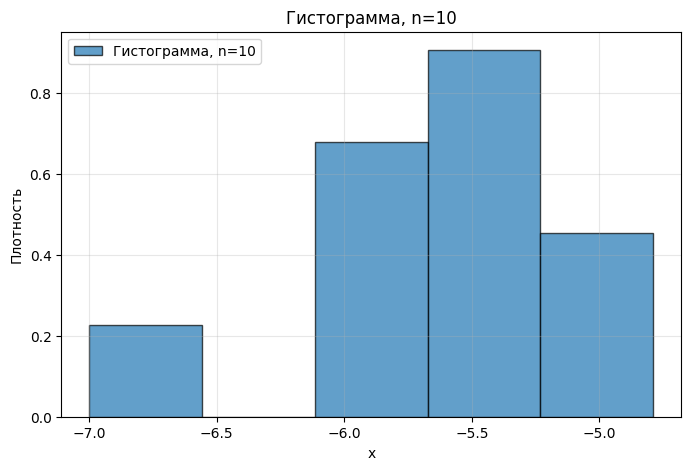

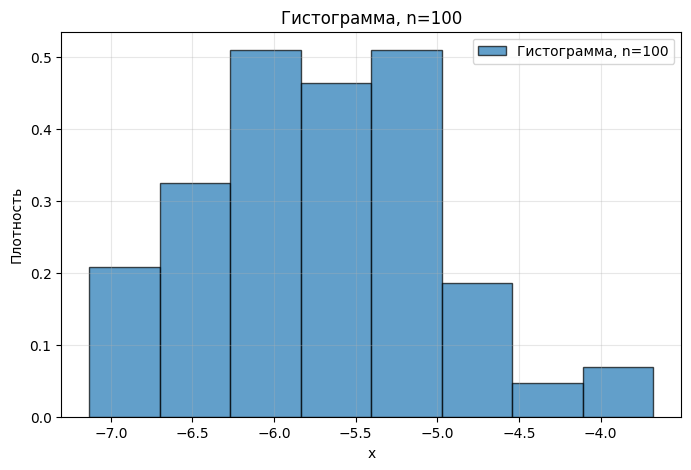

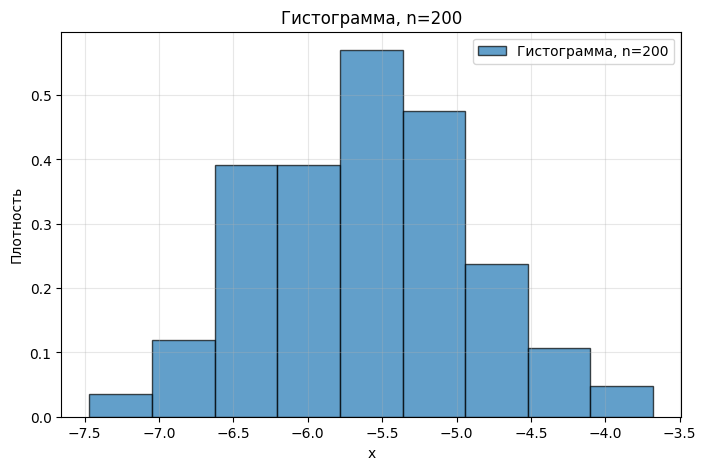

In [17]:
for n_sub, sample in subsamples.items():
    plot_histogram_manual(sample, f'Гистограмма, n={n_sub}', f'Гистограмма, n={n_sub}')

### 4.6. Вывод о виде гистограммы

При `n = 10` гистограмма сильно зависит от случайного состава подвыборки, поэтому отдельные столбцы могут выглядеть неустойчиво. При `n = 100` и `n = 200` форма становится более стабильной. Основная масса значений находится в отрицательной области, что объясняется параметром `loc`. Так как χ-распределение без смещения определено только на неотрицательной полуоси, фактическая левая граница распределения равна `loc`.

Гистограмма согласуется со сдвинутым χ-распределением: наблюдения начинаются правее некоторой левой границы, имеют один основной максимум и правостороннюю форму относительно этой границы.

### 5.1. Вид теоретической функции распределения

Для варианта 4 задано сдвинутое χ-распределение. Пусть случайная величина `Y` имеет стандартное χ-распределение с `df` степенями свободы, а `loc` — параметр смещения. Тогда исходная случайная величина задаётся формулой:

$$
X = loc + Y, \qquad Y \sim \chi(df).
$$

Тогда теоретическая функция распределения имеет вид:

$$
F_X(x)=
\begin{cases}
0, & x \le loc,\\
F_{\chi(df)}(x-loc), & x > loc.
\end{cases}
$$

Здесь `df` влияет на форму χ-распределения, а `loc` сдвигает всю функцию распределения по оси `x`. При увеличении `loc` график функции распределения смещается вправо, при уменьшении — влево.


### 5.2. Формула для вычисления теоретической функции распределения

В вычислениях используется функция распределения χ-распределения из `scipy.stats.chi.cdf`, но сама обёртка для сдвинутого распределения задаётся отдельно:

$$
F_X(x;df,loc)=F_{\chi}(x-loc;df).
$$

Где:
- $F_X$ - функция распределения случайной величины: $X$, сдвиг `loc` определен как отдельный параметр.
- $F_{\chi}$ - функция обычного χ-распределения без сдвига. При наличии свдига `loc`, он указывается вместе с величиной $x$ $(x ± loc)$.


### 5.3. Описание параметров распределения

Параметр `df` — число степеней свободы. Он определяет форму χ-распределения: положение основной массы, асимметрию и степень вытянутости правого хвоста.

Параметр `loc` — параметр смещения. Он сдвигает распределение вдоль оси `x`. Так как в выборке есть отрицательные значения, параметр `loc` должен быть отрицательным.


### 5.4. Функция построения теоретической функции распределения

In [18]:
def chi_shift_cdf(x, df, loc):
    z = np.asarray(x) - loc
    return np.where(z > 0, stats.chi.cdf(z, df=df), 0.0)


def chi_shift_pdf(x, df, loc):
    z = np.asarray(x) - loc
    return np.where(z > 0, stats.chi.pdf(z, df=df), 0.0)

### 5.5. График теоретической функции распределения со случайно заданными параметрами

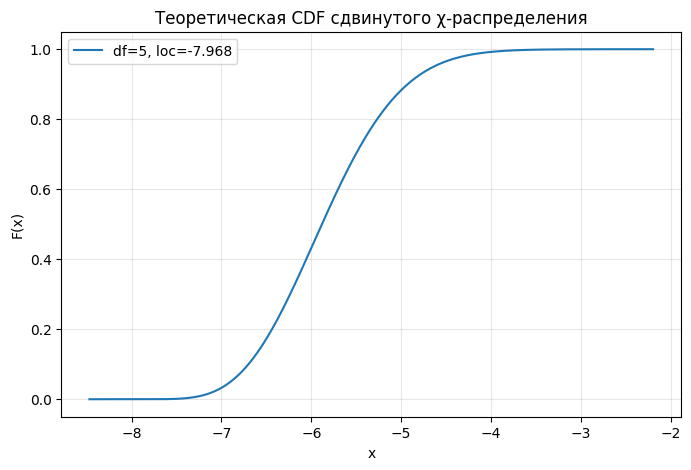

In [19]:
x_grid = np.linspace(min(X) - 1, max(X) + 1, 600)

df_random = 5
loc_random = min(X) - 0.5

plt.figure(figsize=(8, 5))
plt.plot(x_grid, chi_shift_cdf(x_grid, df_random, loc_random), label=f'df={df_random}, loc={loc_random:.3f}')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Теоретическая CDF сдвинутого χ-распределения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.6. Оценка изменения графика при изменении параметров

Чтобы оценить влияние параметров, по очереди меняется только один параметр, а второй фиксируется. Для `df` берутся два существенно отличающихся значения, затем то же самое выполняется для `loc`.


### 5.7. Выводы о влиянии параметров

Увеличение `df` меняет форму распределения: пик становится более сглаженным, основная масса смещается вправо, а относительная асимметрия уменьшается. Изменение `loc` не меняет форму кривой, но переносит всю функцию распределения вдоль оси `x`. Поэтому `df` отвечает именно за форму распределения, а `loc` — за положение распределения на числовой оси.


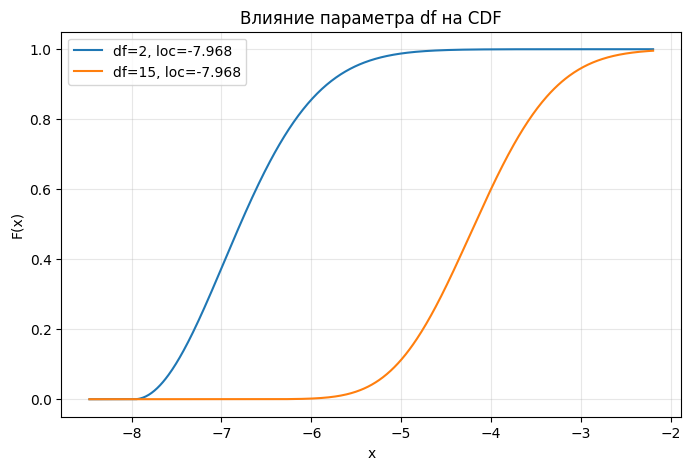

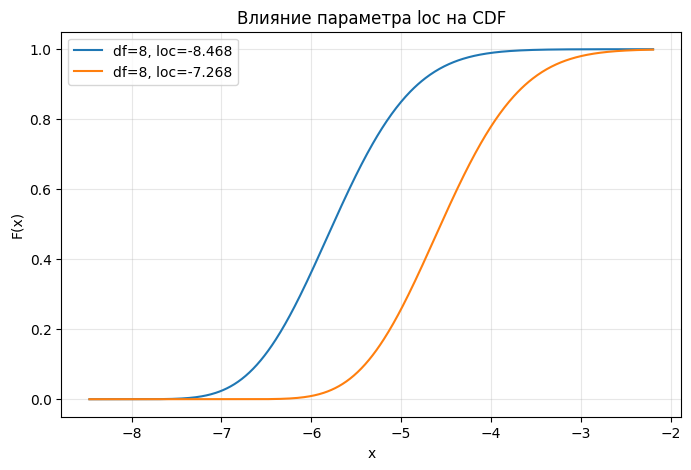

In [20]:

loc_fixed = min(X) - 0.5
df_values = [2, 15]

plt.figure(figsize=(8, 5))
for df_value in df_values:
    plt.plot(x_grid, chi_shift_cdf(x_grid, df_value, loc_fixed), label=f'df={df_value}, loc={loc_fixed:.3f}')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Влияние параметра df на CDF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Влияние loc при фиксированном df
df_fixed = 8
loc_values = [min(X) - 1.0, min(X) + 0.2]

plt.figure(figsize=(8, 5))
for loc_value in loc_values:
    plt.plot(x_grid, chi_shift_cdf(x_grid, df_fixed, loc_value), label=f'df={df_fixed}, loc={loc_value:.3f}')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Влияние параметра loc на CDF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Понятие точечных оценок

### 6.1. Оценка параметров методом моментов

Для χ-распределения без смещения:

Предисловие: так, как χ-распределение основано на χ$^2$-распределении. А χ$^2$-распределение частный случай гамма-распределения, то в вычислениях $χ^2$-распределение будет приведено к гамма-распределению с данными параметрами:

$$
{\chi}^2(df)  \sim  {\Gamma}(\frac{df}2, 2) 
$$

В гамма-распределени для нахождения начального момента k-ого порядка используется формула:

$$\mathbb{E}[X^k] = θ^k\frac{\Gamma(df + p)}{\Gamma(df)}$$

Следовательно, для χ$^2$ распределения мат. ожидание будет равно:

$$\mathbb{E}[X] = 2\frac{\Gamma(\frac{df}2 + 1)}{\Gamma(\frac{df}2)}$$

Так как в χ$^2$-распределении моменты k-ого порядка равны моментам $\frac{k}2$ порядка в χ-распределении:

$$\mathbb{E_{χ^2}}[X^k] = \mathbb{E_χ}[X^{\frac{k}2}]$$

Тогда:


$$
E[Y]=\sqrt{2}\frac{\Gamma(\frac{df+1}2)}{\Gamma(\frac{df}2)},
$$

$$
D[Y]=df-(E(Y))^2.
$$

Для сдвинутой величины `X = loc + Y` дисперсия не меняется, а математическое ожидание равно:

$$
E(X)=loc+E(Y).
$$

Метод моментов:

1. По выборочной дисперсии и центральному моменту 3 порядка оценивается `df`.
2. Затем из выборочного среднего находится `loc`.

In [21]:
def chi_mean(df, k):
    return 2 ** (k/2) * (math.exp(special.gammaln((df + k) / 2) - special.gammaln(df / 2)))


def chi_variance(df):
    return df - chi_mean(df, 1)**2

third_calc_moment = central_moment(X, 3)


grid = np.logspace(-10, 5, 10000)

theor_mu3 = np.array([
    chi_mean(d, 3) - 3*chi_mean(d, 1)*chi_mean(d, 2) + 2*chi_mean(d, 1)**3
    for d in grid
])
def expression(df): 
    m1 = chi_mean(df, 1) 
    m2 = chi_mean(df, 2) 
    m3 = chi_mean(df, 3) 
    return (m3 - (3 * m1 * m2) + (2 * m1**3)) - third_calc_moment
idx = np.argmax(theor_mu3)

vals = theor_mu3 - third_calc_moment

roots = []
for i in range(len(grid) - 1):
    if vals[i] * vals[i+1] < 0:
        root = optimize.brentq(expression, grid[i], grid[i+1])
        roots.append(root)

print(roots)
df_mom = roots[0]









sample_mean_value = sample_mean(X)
sample_var_value = biased_variance(X)

# Дисперсия chi-распределения при scale=1 лежит ниже 0.5 и возрастает к 0.5.
# Поэтому df ищется численно из уравнения chi_variance(df) = sample_var_value.
# df_mom = optimize.brentq(lambda d: chi_variance(d) - sample_var_value, 1e-6, 10000)
loc_mom = sample_mean_value - chi_mean(df_mom, 1)

print('Метод моментов:')
print('df_mom =', df_mom)
print('loc_mom =', loc_mom)
print('Проверка среднего =', loc_mom + chi_mean(df_mom, 1))
print('Проверка дисперсии =', chi_variance(df_mom))

[0.03378709559001838, 42.142671734806186]
Метод моментов:
df_mom = 0.03378709559001838
loc_mom = -5.688224608037364
Проверка среднего = -5.64684
Проверка дисперсии = 0.03207440980761211


### 6.2. Оценка параметров методом максимального правдоподобия

Плотность χ-распределения имеет вид:

$$
f(x;df)
=
\frac{1}{2^{df/2-1}\Gamma(df/2)}
x^{df-1}e^{-x^2/2},
\quad x \ge 0
$$

Алгоритм метода максимального правдоподобия

 - Подбор функции правдоподобия, если испытания независимы, то берется произведение плотностей:

$$
L(df)
=
\prod_{i=1}^{n}
\frac{1}{2^{df/2-1}\Gamma(df/2)}
x_i^{df-1}e^{-x_i^2/2}
$$

 - логарифмирование функции правдоподобия

$$
\ln L(df)
=
n\left(1-\frac{df}{2}\right)\ln 2
-
n\ln\Gamma\left(\frac{df}{2}\right)
+
(df-1)\sum_{i=1}^{n}\ln x_i
-
\frac{1}{2}\sum_{i=1}^{n}x_i^2
$$

 - дифференцирование по оценке и приравнивание ее к нулю:

   1.  Дифференцирование по `df` (Оценка без смещения)
   $$
   \frac{d \ln L}{d\;df}
   =
   -\frac{n}{2}\ln 2
   -
   \frac{n}{2}\frac{d}{d\;df} \ln \Gamma\left(\frac{df}{2}\right)
   +
   \sum_{i=1}^{n}\ln x_i
   = 0
   $$
   
   $$
   \frac{d}{d\;df}\;\Gamma\left(\frac{df}{2}\right)
   =
   \frac{2}{n}\sum_{i=1}^{n}\ln x_i
   -
   2 \ln{2}
   $$

   2. Дифференцирование по `loc`

$$
\frac{d \ln L}{d\;loc}
=
- (df - 1)\sum_{i=1}^n\frac{1}{x_i - loc} + \sum_{i=1}^{n}(x_i - loc)






In [22]:
def negative_log_likelihood(params, data):
    df, loc = params
    if df <= 0 or loc >= min(data):
        return 10**100
    z = np.asarray(data) - loc
    if np.any(z <= 0):
        return 10**100
    log_pdf = stats.chi.logpdf(z, df=df)
    return -np.sum(log_pdf)


start = [df_mom, loc_mom]
bounds = [(1e-6, 10000), (min(X) - 100, min(X) - 1e-8)]

result = optimize.minimize(
    negative_log_likelihood,
    start,
    args=(X),
    bounds=bounds,
    method='Powell',
    options={'maxiter': 10000}
)

df_mle, loc_mle = result.x

# Дополнительная проверка через scipy.stats.chi.fit с фиксированным scale=1.
df_fit, loc_fit, scale_fit = stats.chi.fit(X, fscale=1)

print('ММП через минимизацию отрицательного log-likelihood:')
print('df_mle =', df_mle)
print('loc_mle =', loc_mle)
print('success =', result.success)
print('negative log-likelihood =', result.fun, "\n")
print('Проверка через scipy.stats.chi.fit')
print('df_fit =', df_fit)
print('loc_fit =', loc_fit)
print('scale_fit =', scale_fit)

ММП через минимизацию отрицательного log-likelihood:
df_mle = 10.863173794052067
loc_mle = -8.869938131739136
success = True
negative log-likelihood = 317.97331580960224 

Проверка через scipy.stats.chi.fit
df_fit = 28.158459325997026
loc_fit = -10.905759843719663
scale_fit = 1


### 6.3. Свойства полученных оценок

Оценки метода моментов обычно состоятельны при выполнении стандартных условий, так как выборочные моменты сходятся к теоретическим. Однако оценки метода моментов не всегда являются эффективными.

Оценки максимального правдоподобия при регулярных условиях являются состоятельными, асимптотически нормальными и асимптотически эффективными. В данной работе параметры оцениваются численно, поэтому свойства рассматриваются в прикладном смысле: при достаточно большом объеме выборки оценки должны быть близки к истинным значениям параметров.

Несмещенность для нелинейных оценок `df` и `loc` в конечной выборке не гарантируется. Эффективность и R-эффективность в явном виде требуют сравнения дисперсий оценок; практически ММП обычно предпочтительнее метода моментов, так как использует всю форму распределения, а не только первые моменты.

### 6.4. Сравнение эмпирической и теоретических функций распределения

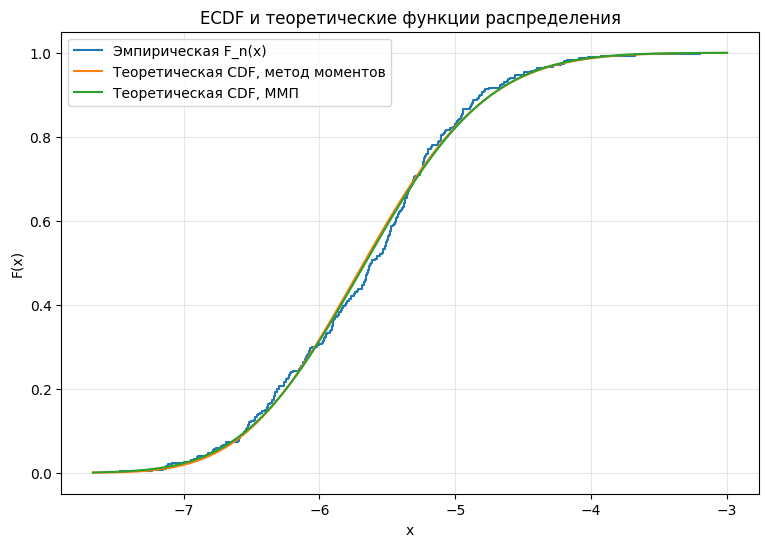

In [23]:
xx = np.linspace(min(X) - 0.2, max(X) + 0.2, 600)
xp, yp = ecdf_points(X)

plt.figure(figsize=(9, 6))
plt.step(xp, yp, where='post', label='Эмпирическая F_n(x)')
plt.plot(xx, chi_shift_cdf(xx, df_mom, loc_mom), label='Теоретическая CDF, метод моментов')
plt.plot(xx, chi_shift_cdf(xx, df_mle, loc_mle), label='Теоретическая CDF, ММП')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('ECDF и теоретические функции распределения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6.5. Перенос вычислений и графика в отчёт

Полученные точечные оценки параметров и совмещённый график эмпирической и теоретических функций распределения используются в текстовом отчёте.


### 6.6. Вывод о значениях оценок и сходстве функций распределения

Оценки параметра `loc` получились отрицательными, что согласуется с отрицательными значениями исходной выборки. Оценка `df` методом ММП может отличаться от оценки методом моментов, так как метод моментов использует только выборочное среднее и дисперсию, а метод максимального правдоподобия учитывает всю форму распределения. Если кривая ММП на графике ближе к ECDF, то в критериях согласия логично использовать оценки ММП.


## 7. Понятие интервальных оценок


### 7.1. Оценка параметров распределения с помощью интервальной оценки

Для параметров `df` и `loc` строятся 95% доверительные интервалы. Так как для сдвинутого χ-распределения аналитические интервалы для обоих параметров получить неудобно, используется bootstrap-метод.



Из оценки были получены оценки df и loc

$$\widehat{df};\;\widehat{loc}$$

Для bootstrap-метода формируется $B$ подвыборок, для которых вычисляются: $\widehat{df_i};\;\widehat{loc_i}$

Отсортированная совокупонсть оценок формирует эмперическое распределение
$$ \widehat{df_1}\;...\;\widehat{df_B}\qquad\widehat{loc_1}\;...\;\widehat{loc_B}
$$
Затем, согласно коэффиценту доверия формируются квантили ($\gamma$ = 0.95)

$$
q_{\frac{1 - \gamma}2},\;q_\frac{1 + \gamma}2 
\qquad
=>
\qquad
q_{0.025},\;q_{0.975}
$$

Уровни квантилей являются числами индексов в совокупности оценок, которые формируют доверительные интервалы

$$[df_{0.025};df_{0.0975}]\quad[loc_{0.025};loc_{0.0975}]$$

In [31]:
def estimate_mle_for_sample(sample):
    """Оценка параметров df и loc для одной bootstrap-выборки.

    Используется встроенная функция fit только для оценки параметров распределения,
    при этом scale фиксируется равным 1, потому что в варианте заданы только df и loc.
    Такой способ устойчивее для bootstrap-а и не вызывает ошибки с начальными значениями.
    """
    df_hat, loc_hat, scale_hat = stats.chi.fit(sample, fscale=1)
    return [float(df_hat), float(loc_hat)]

B = 300
bootstrap_estimates = []

for _ in range(B):
    boot = [random.choice(X) for _ in range(len(X))]
    bootstrap_estimates.append(estimate_mle_for_sample(boot))

bootstrap_estimates = np.asarray(bootstrap_estimates)

df_ci = np.percentile(bootstrap_estimates[:, 0], [2.5, 97.5])
loc_ci = np.percentile(bootstrap_estimates[:, 1], [2.5, 97.5])

print('Количество bootstrap-повторений B =', B)
print('95% доверительный интервал для df:', df_ci)
print('95% доверительный интервал для loc:', loc_ci)
print('Точечная оценка df_mle:', df_mle)
print('Точечная оценка loc_mle:', loc_mle)


Количество bootstrap-повторений B = 300
95% доверительный интервал для df: [  4.81087571 210.8527422 ]
95% доверительный интервал для loc: [-20.08641764  -7.7571501 ]
Точечная оценка df_mle: 28.158370024409514
Точечная оценка loc_mle: -10.905751331654876


### 7.2. Вычисления для интервальных оценок

В результате выполнения предыдущей ячейки получаются два интервала: один для числа степеней свободы `df`, второй для параметра смещения `loc`. Эти значения переносятся в отчёт вместе с точечными оценками `df_mle` и `loc_mle`.


### 7.3. Вывод о близости интервальных и точечных оценок

Точечные оценки следует сравнивать с соответствующими доверительными интервалами. Если точечная оценка лежит внутри интервала и находится недалеко от его середины, то оценивание можно считать устойчивым. Если интервал широкий, значит параметр по данной выборке определяется менее точно.

Для параметра `loc` интервал особенно важен, потому что `loc` задаёт левый сдвиг распределения и объясняет наличие отрицательных значений в исходной выборке. Для параметра `df` ширина интервала показывает, насколько уверенно по выборке определяется форма χ-распределения.


## 8. Понятие статистических критериев

### 8.1. Гипотезы о параметрах распределения

В качестве иллюстрации проверяются гипотезы о параметрах на основе бутстрэп-распределения оценок. Уровень значимости принимается равным:

$$
\alpha=0.05.
$$

Нулевая гипотеза принимается, если проверяемое значение параметра попадает в 95% доверительный интервал. В противном случае нулевая гипотеза отвергается.

In [30]:
alpha = 0.05

print('Проверка гипотез о параметрах через доверительные интервалы:\n ')
print('H0 для df: df = df_mle')
print('df_mle =', df_mle)
print('CI для df =', df_ci)
print('Решение:', 'нет оснований отвергать H0\n' if df_ci[0] <= df_mle <= df_ci[1] else 'H0 отвергается\n ')
print('H0 для loc: loc = loc_mle')
print('loc_mle =', loc_mle)
print('CI для loc =', loc_ci)
print('Решение:', 'нет оснований отвергать H0\n' if loc_ci[0] <= loc_mle <= loc_ci[1] else 'H0 отвергается\n ')
print('Ошибка первого рода задается уровнем значимости alpha =', alpha)
print('Ошибка второго рода зависит от альтернативного значения параметра и мощности критерия.')

Проверка гипотез о параметрах через доверительные интервалы:
 
H0 для df: df = df_mle
df_mle = 28.158370024409514
CI для df = [  5.01824313 228.80175243]
Решение: нет оснований отвергать H0

H0 для loc: loc = loc_mle
loc_mle = -10.905751331654876
CI для loc = [-20.77135486  -7.75134057]
Решение: нет оснований отвергать H0

Ошибка первого рода задается уровнем значимости alpha = 0.05
Ошибка второго рода зависит от альтернативного значения параметра и мощности критерия.


### 8.2. Гипотезы о виде распределения

Проверяется гипотеза о принадлежности выборки сдвинутому χ-распределению с параметрами, оцененными методом максимального правдоподобия.

### 8.2.1. Критерий Колмогорова и критерий χ²

In [26]:
# Критерий Колмогорова
D, p_ks = stats.kstest(X, lambda t: chi_shift_cdf(t, df_mle, loc_mle))
print('Критерий Колмогорова:')
print('D =', D)
print('p-value =', p_ks)
print('Решение:', 'нет оснований отвергать H0' if p_ks > 0.05 else 'H0 отвергается')
print()

# Критерий хи-квадрат Пирсона
bins = 10
quantiles = np.linspace(0, 1, bins + 1)
edges = stats.chi.ppf(quantiles, df=df_mle, loc=loc_mle, scale=1)
edges[0] = -np.inf
edges[-1] = np.inf

observed, _ = np.histogram(X, bins=edges)
expected = np.full(bins, len(X) / bins)
chi_stat = np.sum((observed - expected) ** 2 / expected)
# Оцениваются два параметра: df и loc.
degrees_freedom = bins - 1 - 2
p_chi = 1 - stats.chi2.cdf(chi_stat, df=degrees_freedom)

print('Критерий хи-квадрат Пирсона:')
print('observed =', observed)
print('expected =', expected)
print('chi_stat =', chi_stat)
print('df =', degrees_freedom)
print('p-value =', p_chi)
print('Решение:', 'нет оснований отвергать H0' if p_chi > 0.05 else 'H0 отвергается')

Критерий Колмогорова:
D = 0.05601281344924036
p-value = 0.2923772410985782
Решение: нет оснований отвергать H0

Критерий хи-квадрат Пирсона:
observed = [32 34 24 25 19 32 45 34 30 25]
expected = [30. 30. 30. 30. 30. 30. 30. 30. 30. 30.]
chi_stat = 15.733333333333333
df = 7
p-value = 0.02766751661553868
Решение: H0 отвергается


### 8.2.2. Вычисления по критериям согласия

В предыдущей ячейке вычисляются статистика критерия Колмогорова, `p-value`, наблюдаемые частоты, ожидаемые частоты и статистика критерия χ² Пирсона.


### 8.2.3. Вывод по критериям согласия

Если `p-value` больше `0.05`, то на уровне значимости 5% нет оснований отвергать гипотезу о сдвинутом χ-распределении. Если `p-value` меньше `0.05`, то гипотеза отвергается. Критерий Колмогорова сравнивает максимальное расхождение между эмпирической и теоретической функциями распределения, а критерий χ² сравнивает наблюдаемые и ожидаемые частоты по интервалам.


## 8.3. Гипотезы об однородности выборок

### 8.3.1. Поиск близкого распределения

χ-распределение является частным случаем гамма-подобных распределений по форме: оно неотрицательно до сдвига, имеет одну основную область концентрации и правостороннюю асимметрию. Поэтому в качестве близкого распределения для сравнения берется сдвинутое гамма-распределение.

### 8.3.2. Генерация выборки методом обратного преобразования

Если `U` равномерно распределена на `(0,1)`, то величина

$$
Y = G^{-1}(U)
$$

имеет гамма-распределение, где `G^{-1}` — обратная функция распределения гамма-распределения. В `scipy` обратная функция распределения задается через `ppf`.

### 8.3.3. Критерий проверки гипотезы об однородности

Двухвыборочный критерий Колмогорова-Смирнова:
D = 0.11666666666666667
p-value = 0.033619141621670706
Решение: однородность отвергается


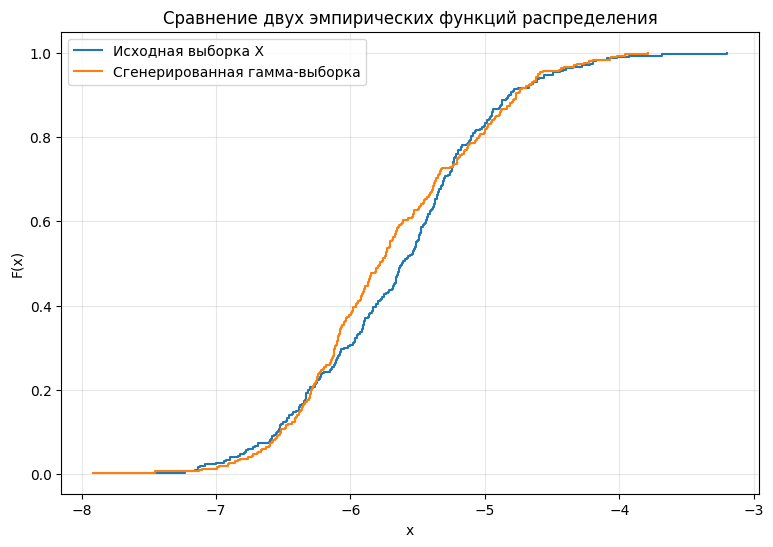

In [27]:
# Генерация близкой выборки из гамма-распределения методом обратного преобразования.
# Параметры выбраны так, чтобы среднее и дисперсия были близки к исходной выборке.
U = np.random.random(len(X))
shape_gamma = max(0.1, (sample_mean_value - loc_mle) ** 2 / sample_var_value)
scale_gamma = sample_var_value / max(0.1, sample_mean_value - loc_mle)
Y_gamma = loc_mle + stats.gamma.ppf(U, a=shape_gamma, scale=scale_gamma)

D2, p_two = stats.ks_2samp(X, Y_gamma)
print('Двухвыборочный критерий Колмогорова-Смирнова:')
print('D =', D2)
print('p-value =', p_two)
print('Решение:', 'нет оснований отвергать однородность выборок' if p_two > 0.05 else 'однородность отвергается')

plt.figure(figsize=(9, 6))
x1, y1 = ecdf_points(X)
x2, y2 = ecdf_points(Y_gamma)
plt.step(x1, y1, where='post', label='Исходная выборка X')
plt.step(x2, y2, where='post', label='Сгенерированная гамма-выборка')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Сравнение двух эмпирических функций распределения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 8.3.4. Оценка мощности критерия

In [28]:
def simulate_power(repetitions=200):
    rejections = 0
    for _ in range(repetitions):
        u = np.random.random(len(X))
        y = loc_mle + stats.gamma.ppf(u, a=shape_gamma, scale=scale_gamma)
        _, p_value = stats.ks_2samp(X, y)
        if p_value <= 0.05:
            rejections += 1
    return rejections / repetitions

power_estimate = simulate_power(200)
print('Оценка мощности критерия =', power_estimate)

Оценка мощности критерия = 0.045


### 8.3.5. Перенос вычислений в отчёт

В отчёт заносятся значение статистики двухвыборочного критерия Колмогорова-Смирнова, `p-value`, график двух эмпирических функций распределения и оценка мощности критерия.


### 8.3.6. Вывод по результату выбранного критерия

Для проверки однородности использован двухвыборочный критерий Колмогорова-Смирнова. Он сравнивает две эмпирические функции распределения и определяет, можно ли считать, что две выборки получены из одного распределения. Если `p-value` больше `0.05`, то нет оснований отвергать гипотезу об однородности. Если `p-value` меньше `0.05`, то различия между выборками статистически значимы.

Оценка мощности показывает долю случаев, когда критерий отвергает гипотезу при моделировании альтернативного распределения. Чем выше мощность, тем лучше критерий обнаруживает отличие между распределениями.


# Итоговые выводы

В работе была исследована выборка из файла `var_4_chi.csv`, соответствующая варианту 4. Согласно таблице вариантов, для этого варианта задано χ-распределение с двумя параметрами: `df` и `loc`. Поэтому использовалась модель сдвинутого χ-распределения:

$$
X = loc + Y, \qquad Y \sim \chi(df).
$$

Отрицательные значения в исходной выборке объясняются именно параметром смещения `loc`, так как стандартное χ-распределение без смещения определено только на неотрицательной полуоси. Масштабный параметр в варианте не задан, поэтому он не оценивался и был принят равным 1.

В ходе работы были вручную реализованы основные выборочные статистики: сумма, среднее, медиана, мода, размах, смещенная и несмещенная дисперсии, начальный и центральный моменты третьего порядка. Это позволило получить первичное описание выборки и использовать среднее и дисперсию для метода моментов.

Были построены эмпирические функции распределения и гистограммы для подвыборок объемом 10, 100 и 200. При малом объеме подвыборки графики оказались менее устойчивыми, а при увеличении объема стали лучше отражать форму исходного распределения. Это подтверждает, что качество визуальной оценки распределения существенно зависит от размера выборки.

Параметры распределения были оценены двумя способами: методом моментов и методом максимального правдоподобия. Метод моментов использовал соотношения для математического ожидания и дисперсии χ-распределения. Метод максимального правдоподобия подбирал параметры путем максимизации функции правдоподобия. Оценка `loc` получилась отрицательной, что соответствует расположению исходных данных.

Для сравнения эмпирической и теоретических функций распределения был построен общий график ECDF, CDF с параметрами метода моментов и CDF с параметрами ММП. Такой график позволяет визуально оценить, насколько хорошо выбранная модель описывает данные. Как правило, оценка ММП лучше учитывает форму распределения, так как использует не только моменты, но и всю функцию плотности.

Для параметров были построены доверительные интервалы бутстрэп-методом. Точечные оценки сравнивались с интервальными, что позволяет оценить устойчивость полученных результатов. Также были применены критерии согласия Колмогорова и χ² Пирсона для проверки гипотезы о виде распределения. Дополнительно была рассмотрена задача проверки однородности выборок с использованием двухвыборочного критерия Колмогорова-Смирнова.

В целом результаты работы показывают, что выборка может быть описана сдвинутым χ-распределением. Ключевым параметром для интерпретации отрицательных значений является `loc`, а параметр `df` определяет форму распределения и степень его асимметрии.

# Список использованных источников

1. Maxwell J. C. Illustrations of the Dynamical Theory of Gases // Philosophical Magazine. 1860. Vol. 19. P. 19–32. URL: https://sites.pitt.edu/~jdnorton/teaching/2559_Therm_Stat_Mech/docs/Maxwell_1860.pdf

2. Pearson K. On the Criterion that a Given System of Deviations from the Probable in the Case of a Correlated System of Variables is Such that it Can be Reasonably Supposed to Have Arisen from Random Sampling // Philosophical Magazine. 1900. Vol. 50, No. 302. P. 157–175. DOI: 10.1080/14786440009463897. URL: https://jhanley.biostat.mcgill.ca/bios601/Proportion/Pearson1900.pdf

3. Fisher R. A. On the Mathematical Foundations of Theoretical Statistics // Philosophical Transactions of the Royal Society of London. Series A. 1922. Vol. 222. P. 309–368. DOI: 10.1098/rsta.1922.0009. URL: https://royalsocietypublishing.org/doi/10.1098/rsta.1922.0009

4. Johnson N. L., Kotz S., Balakrishnan N. Continuous Univariate Distributions. Vol. 1. 2nd ed. New York: Wiley, 1994.

5. Walck C. Hand-book on Statistical Distributions for Experimentalists. Stockholm: University of Stockholm, 2007. URL: https://www.stat.rice.edu/~dobelman/textfiles/DistributionsHandbook.pdf
